In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Project 6: FitzHugh-Nagumo and excitability

MCSB Bootcamp — Mathematical and Computational Track

Jun Allard

## Background, model, and Part I

The phenomenon of excitability exists in many biological systems,
including in the electrophysiology of neurons. The FitzHugh-Nagumo
equations

$$\begin{aligned}
\frac{dv}{dt} &= v - \frac{1}{3} v^3 - w \\
\frac{dw}{dt} &= \epsilon \left( v + a - bw\right)
\end{aligned}$$

describe neuron electrophysiology where, roughly speaking, $v$ is the
electrical potential (voltage) across the cell’s membrane, and $w$ is
the activity of ion pumps. The parameters $\epsilon$, $a$ and $b$
represent properties of the ion pumps. The model has been
nondimensionalized. Both $v$ and $w$ can be negative or positive.

a.  Confirm that for $\epsilon=0.08$, $a=0.5$, $b=0.2$, the system is
    oscillatory.

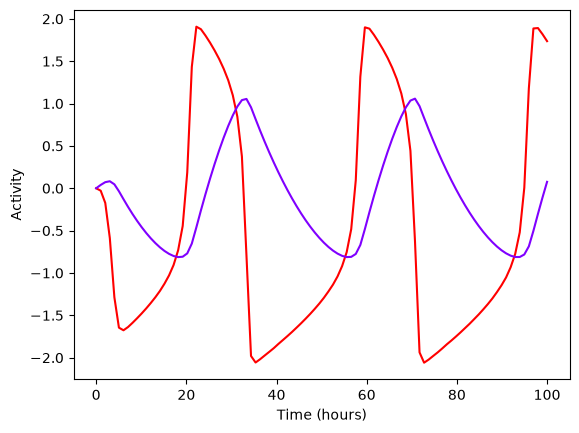

In [10]:
def dxdt(t, state):
    """dA/dt, dAP/dt, dI/dt, and dIK/dt for the protein, kinase, phosphotase system, given the state [i, a, ap, ik]."""
    v,w =state
    dv_dt=v-1/3*v**3-w
    dw_dt= 0.08*(v+0.5-0.2*w)

    return dv_dt, dw_dt



sol = solve_ivp(dxdt, [0, 100], [0.0, 0.0], t_eval=np.linspace(0, 100, 100))
T = sol.t
v,w = sol.y

fig, ax = plt.subplots()
ax.plot(T, v, "-r")
ax.plot(T, w, "-", color=[0.5, 0, 1])

ax.set_ylabel("Activity")
ax.set_xlabel("Time (hours)")
plt.show()

b.  Confirm that for $\epsilon=0.08$, $a=1.0$, $b=0.2$, the system has
    the following property: if you choose initial conditions
    $v(0)=-1.5$, $w(0)=-0.5$, the system evolves directly towards a
    stable steady state, but if you choose initial conditions
    $v(0)=0.0$, $w(0)=-0.5$, the system moves away from the steady state
    before eventually converging towards it. This behavior is called
    *excitability*. At these parameters, what is the steady state value
    of $v$ and $w$?

Steady state of v:-1.1303400984486707, w:-0.6489369499111819


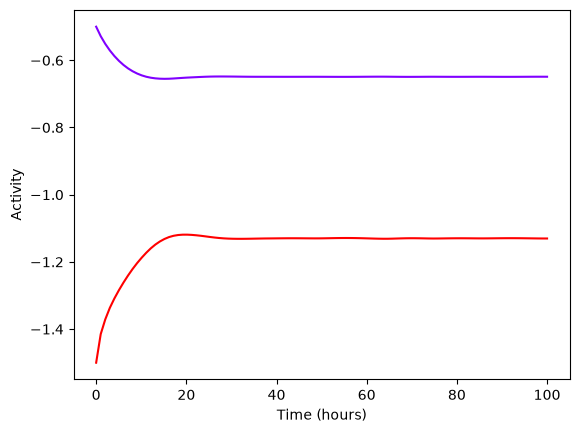

Steady state of v:-1.130696761643988, w:-0.6490593501213486


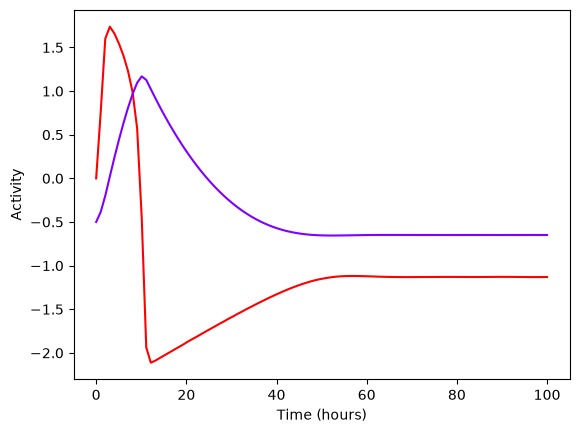

In [7]:
def dxdt(t, state):
    """dA/dt, dAP/dt, dI/dt, and dIK/dt for the protein, kinase, phosphotase system, given the state [i, a, ap, ik]."""
    v,w =state
    dv_dt=v-1/3*v**3-w
    dw_dt= 0.08*(v+1-0.2*w)

    return dv_dt, dw_dt
sol = solve_ivp(dxdt, [0, 100], [-1.5, -0.5], t_eval=np.linspace(0, 100, 100))
T = sol.t
v,w = sol.y
print(f'Steady state of v:{v[-1]}, w:{w[-1]}')
fig, ax = plt.subplots()
ax.plot(T, v, "-r")
ax.plot(T, w, "-", color=[0.5, 0, 1])

ax.set_ylabel("Activity")
ax.set_xlabel("Time (hours)")
plt.show()

sol = solve_ivp(dxdt, [0, 100], [0.0, -0.5], t_eval=np.linspace(0, 100, 100))
T = sol.t
v,w = sol.y
print(f'Steady state of v:{v[-1]}, w:{w[-1]}')
fig, ax = plt.subplots()
ax.plot(T, v, "-r")
ax.plot(T, w, "-", color=[0.5, 0, 1])

ax.set_ylabel("Activity")
ax.set_xlabel("Time (hours)")
plt.show()

## Part II: Current injection

Assume the neuron is at rest (at its steady state), and another cell
injects a current into it. The current is injected between $t=40$ and
$t=47$, and has a strength of $I_0=1.0$. In the model, this means

$$\begin{aligned}
\frac{dv}{dt} &= v - \frac{1}{3} v^3 - w + I(t)\\
\frac{dw}{dt} &= \epsilon \left( v + a - bw\right)
\end{aligned}$$

where

$$I(t) = \begin{cases}
I_0 & \qquad t_\mathrm{start} < t < t_\mathrm{stop}\\
0 & \qquad \text{otherwise}
\end{cases}$$

or, in code,

``` python
I0 = 1.0
t_start = 40
t_stop = 47


def I(t):
    return I0 * (t > t_start) * (t < t_stop)
```

c.  At the excitable parameters from above ($a=1.0$), simulate the
    system with initial conditions at the steady state (or very close),
    and simulate a 7-second injection starting at $t=40$ as above.

Steady state of v:-1.1196283573638708, w:-0.6506243035735632


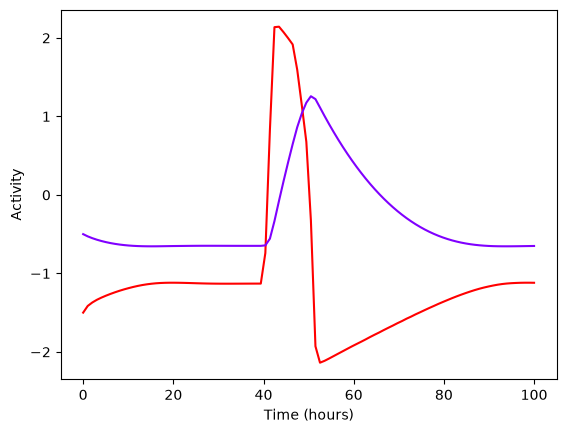

In [11]:
I0 = 1.0
t_start = 40
t_stop = 47


def I(t):
    return I0 * (t > t_start) * (t < t_stop)
def dxdt(t, state):
    """dA/dt, dAP/dt, dI/dt, and dIK/dt for the protein, kinase, phosphotase system, given the state [i, a, ap, ik]."""
    v,w =state
    dv_dt=v-1/3*v**3-w+I(t)
    dw_dt= 0.08*(v+1-0.2*w)

    return dv_dt, dw_dt
sol = solve_ivp(dxdt, [0, 100], [-1.5, -0.5], t_eval=np.linspace(0, 100, 100))
T = sol.t
v,w = sol.y
print(f'Steady state of v:{v[-1]}, w:{w[-1]}')
fig, ax = plt.subplots()
ax.plot(T, v, "-r")
ax.plot(T, w, "-", color=[0.5, 0, 1])

ax.set_ylabel("Activity")
ax.set_xlabel("Time (hours)")
plt.show()

## Part III: Ring of ten cells

Neurons are connected in a neural network. Suppose there are ten cells,
each with membrane potential and ion pump activity obeying the
FitzHugh-Nagumo equations for $v_i(t)$ and $w_i(t)$ where
$i=1 \ldots 10$ indexes the cells. The cells are electrically connected
so that

$$\begin{aligned}
\frac{dv_i}{dt} &= v_i - \frac{1}{3} v_i^3 - w_i + I_i(t) + D\left( v_{i-1} - 2 v_i + v_{i+1}\right)\\
\frac{dw_i}{dt} &= \epsilon \left( v_i + a - bw_i\right)
\end{aligned}$$

where $D=0.9$ is a new parameter that describes the electrical
connectivity of the neighboring cells. The ion pumps are not connected
between cells, so the $w$ equation is unchanged. For simplicity, let’s
assume the cells are connected in a ring, so that

$$\frac{dv_1}{dt} = v_1 - \frac{1}{3} v_1^3 - w_1 + I_1(t) + D\left( v_{10} - 2 v_1 + v_{2}\right)$$

and similarly for the tenth cell,

$$\frac{dv_{10}}{dt} = v_{10} - \frac{1}{3} v_{10}^3 - w_{10} + I_{10}(t) + D\left( v_{9} - 2 v_{10} + v_{1}\right).$$

d.  Write code to simulate these ten cells. There will be 20 equations,
    $v$ and $w$ for each cell.

Steady state of v:-1.1196283573638708, w:-0.6506243035735632


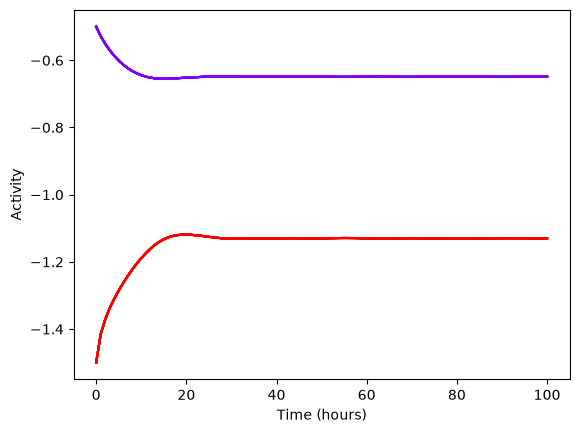

In [26]:
I0 = 1.0
t_start = 40
t_stop = 470


def I(t):
    return I0 * (t > t_start) * (t < t_stop)*0

def dxdt(t, state):
    """dA/dt, dAP/dt, dI/dt, and dIK/dt for the protein, kinase, phosphotase system, given the state [i, a, ap, ik]."""
    v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10 =state
    dv1_dt=v1-1/3*v1**3-w1+I(t)+0.9*(v10-2*v1+v2)
    dv2_dt=v2-1/3*v2**3-w2+I(t)+0.9*(v1-2*v2+v3)
    dv3_dt=v3-1/3*v3**3-w3+I(t)+0.9*(v2-2*v3+v4)
    dv4_dt=v4-1/3*v4**3-w4+I(t)+0.9*(v3-2*v4+v5)
    dv5_dt=v5-1/3*v5**3-w5+I(t)+0.9*(v4-2*v5+v6)
    dv6_dt=v6-1/3*v6**3-w6+I(t)+0.9*(v5-2*v6+v7)
    dv7_dt=v7-1/3*v7**3-w7+I(t)+0.9*(v6-2*v7+v8)
    dv8_dt=v8-1/3*v8**3-w8+I(t)+0.9*(v7-2*v8+v9)
    dv9_dt=v9-1/3*v9**3-w9+I(t)+0.9*(v8-2*v9+v10)
    dv10_dt=v10-1/3*v10**3-w10+I(t)+0.9*(v9-2*v10+v1)
    dw1_dt= 0.08*(v1+1-0.2*w1)
    dw2_dt= 0.08*(v2+1-0.2*w2)
    dw3_dt= 0.08*(v3+1-0.2*w3)
    dw4_dt= 0.08*(v4+1-0.2*w4)
    dw5_dt= 0.08*(v5+1-0.2*w5)
    dw6_dt= 0.08*(v6+1-0.2*w6)
    dw7_dt= 0.08*(v7+1-0.2*w7)
    dw8_dt= 0.08*(v8+1-0.2*w8)
    dw9_dt= 0.08*(v9+1-0.2*w9)
    dw10_dt= 0.08*(v10+1-0.2*w10)
    return dv1_dt, dv2_dt,dv3_dt,dv4_dt,dv5_dt,dv6_dt,dv7_dt,dv8_dt,dv9_dt,dv10_dt,dw1_dt,dw2_dt,dw3_dt,dw4_dt,dw5_dt,dw6_dt,dw7_dt,dw8_dt,dw9_dt,dw10_dt
sol = solve_ivp(dxdt, [0, 100], [-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5, -0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5], t_eval=np.linspace(0, 100, 100))
T = sol.t
v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10 = sol.y
print(f'Steady state of v:{v[-1]}, w:{w[-1]}')
fig, ax = plt.subplots()
ax.plot(T, v1, "-r")
ax.plot(T, v2, "-r")
ax.plot(T, v3, "-r")
ax.plot(T, v4, "-r")
ax.plot(T, v5, "-r")
ax.plot(T, v6, "-r")
ax.plot(T, v7, "-r")
ax.plot(T, v8, "-r")
ax.plot(T, v9, "-r")
ax.plot(T, v10, "-r")
ax.plot(T, w1, "-", color=[0.5, 0, 1])
ax.plot(T, w2, "-", color=[0.5, 0, 1])
ax.plot(T, w3, "-", color=[0.5, 0, 1])
ax.plot(T, w4, "-", color=[0.5, 0, 1])
ax.plot(T, w5, "-", color=[0.5, 0, 1])
ax.plot(T, w6, "-", color=[0.5, 0, 1])
ax.plot(T, w7, "-", color=[0.5, 0, 1])
ax.plot(T, w8, "-", color=[0.5, 0, 1])
ax.plot(T, w9, "-", color=[0.5, 0, 1])
ax.plot(T, w10, "-", color=[0.5, 0, 1])

ax.set_ylabel("Activity")
ax.set_xlabel("Time (hours)")
plt.show()

i.  Assume there is no injection current. We expect all ten cells to
    settle at the same steady state. Make two plots. First, plot a time
    series of the membrane potential of all ten cells as a function of
    time. Second, make a movie of the voltage in all ten cells, where
    the horizontal axis is the cell number.

``` python
# movie
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots()
(line,) = ax.plot(V[0])
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel("Cell")
ax.set_ylabel("Voltage")


def frame(nt):
    line.set_ydata(V[nt])
    return (line,)


movie = animation.FuncAnimation(fig, frame, frames=len(T), interval=30)
plt.close(fig)  # otherwise the first frame is drawn a second time, as a still
HTML(movie.to_jshtml())
```

where `V[nt]` is the voltage of all ten cells at time `T[nt]`.

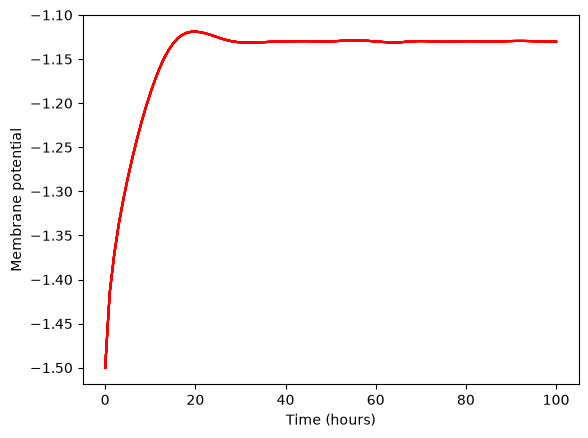

In [27]:
fig, ax = plt.subplots()
ax.plot(T, v1, "-r")
ax.plot(T, v2, "-r")
ax.plot(T, v3, "-r")
ax.plot(T, v4, "-r")
ax.plot(T, v5, "-r")
ax.plot(T, v6, "-r")
ax.plot(T, v7, "-r")
ax.plot(T, v8, "-r")
ax.plot(T, v9, "-r")
ax.plot(T, v10, "-r")

ax.set_ylabel("Membrane potential")
ax.set_xlabel("Time (hours)")
plt.show()
# movie
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots()
V = np.array([v1, v2, v3, v4, v5, v6, v7, v8, v9, v10]).T  

(line,) = ax.plot(V[0])
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel("Cell")
ax.set_ylabel("Voltage")


def frame(nt):
    line.set_ydata(V[nt])
    return (line,)


movie = animation.FuncAnimation(fig, frame, frames=len(T), interval=30)
plt.close(fig)  # otherwise the first frame is drawn a second time, as a still
HTML(movie.to_jshtml())

ii. Now assume that the fourth cell (and only the fourth cell) receives
    an injection current $I(t)$ as above, between $t=40$ and $t=47$.
    Make a time series with all ten cells. Make a movie with the voltage
    for all cells.[1]

Hint: You do not need to make it generalize to different numbers of
cells. In other words, don’t try to make it work for an arbitrary number
of cells and then set the number of cells to 10. Just make it work for
10 cells. (Unless you want to make it generalized.)

[1] This type of behavior is called an *excitable traveling wave pulse*.
These are unlike the harmonic pulses familiar from sound waves,
vibrations, and light. For example, when two excitable pulses collide,
they annihilate.

In [ ]:
I0 = 1.0
t_start = 40
t_stop = 47


def I(t):
    return I0 * (t > t_start) * (t < t_stop)

def dxdt(t, state):
    """dA/dt, dAP/dt, dI/dt, and dIK/dt for the protein, kinase, phosphotase system, given the state [i, a, ap, ik]."""
    v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10 =state
    dv1_dt=v1-1/3*v1**3-w1+I(t)*0+0.9*(v10-2*v1+v2)
    dv2_dt=v2-1/3*v2**3-w2+I(t)*0+0.9*(v1-2*v2+v3)
    dv3_dt=v3-1/3*v3**3-w3+I(t)*0+0.9*(v2-2*v3+v4)
    dv4_dt=v4-1/3*v4**3-w4+I(t)+0.9*(v3-2*v4+v5)
    dv5_dt=v5-1/3*v5**3-w5+I(t)*0+0.9*(v4-2*v5+v6)
    dv6_dt=v6-1/3*v6**3-w6+I(t)*0+0.9*(v5-2*v6+v7)
    dv7_dt=v7-1/3*v7**3-w7+I(t)*0+0.9*(v6-2*v7+v8)
    dv8_dt=v8-1/3*v8**3-w8+I(t)*0+0.9*(v7-2*v8+v9)
    dv9_dt=v9-1/3*v9**3-w9+I(t)*0+0.9*(v8-2*v9+v10)
    dv10_dt=v10-1/3*v10**3-w10+I(t)*0+0.9*(v9-2*v10+v1)
    dw1_dt= 0.08*(v1+1-0.2*w1)
    dw2_dt= 0.08*(v2+1-0.2*w2)
    dw3_dt= 0.08*(v3+1-0.2*w3)
    dw4_dt= 0.08*(v4+1-0.2*w4)
    dw5_dt= 0.08*(v5+1-0.2*w5)
    dw6_dt= 0.08*(v6+1-0.2*w6)
    dw7_dt= 0.08*(v7+1-0.2*w7)
    dw8_dt= 0.08*(v8+1-0.2*w8)
    dw9_dt= 0.08*(v9+1-0.2*w9)
    dw10_dt= 0.08*(v10+1-0.2*w10)
    return dv1_dt, dv2_dt,dv3_dt,dv4_dt,dv5_dt,dv6_dt,dv7_dt,dv8_dt,dv9_dt,dv10_dt,dw1_dt,dw2_dt,dw3_dt,dw4_dt,dw5_dt,dw6_dt,dw7_dt,dw8_dt,dw9_dt,dw10_dt
sol = solve_ivp(dxdt, [0, 100], [-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5,-1.5, -0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5,-0.5], t_eval=np.linspace(0, 100, 100))
T = sol.t
v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10 = sol.y
# movie
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots()
V = np.array([v1, v2, v3, v4, v5, v6, v7, v8, v9, v10]).T 
cells = np.arange(1, 11)
(line,) = ax.plot(V[0])
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel("Cell")
ax.set_ylabel("Voltage")


def frame(nt):
    line.set_ydata(V[nt])
    return (line,)


movie = animation.FuncAnimation(fig, frame, frames=len(T), interval=30)
plt.close(fig)  # otherwise the first frame is drawn a second time, as a still
HTML(movie.to_jshtml())